## Advanced Regression Assignment

a US based housing company name Surprise Housing has decided to enter Australian market. The company business model is to buy the houses at below the actual arket value and when time comes sell it for higher prices. 

To accomplish this objective of this assignment is to predict the house sale price for the given data set. based on the model company wanted to know which variables are significant influencing the price of a house and how well these properties are describing the price of house.

#### Business Objective

- Identify the variables significantly influence the house prices 
- Explain how well these parameters describes the price of the house.

### Approches

##### 1 Perform EDA 
##### 2 Feature Engineering
##### 3 Model Development (CV and comparing different regularization technique)
##### 4 Selecting Optimum Model 
##### 5 Model Evaluation on Test data set 
##### 6 Final Model conclusions.

In [91]:
# Loading Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 500)
%matplotlib inline 

#model building and selection libraries 
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

#model evaluation 
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error


from IPython.display import Markdown, display
def printmd(string):
    display(Markdown(string))
    



# Data File Path
data_file =f"Data/train.csv"

In [96]:

#data Set loading
data_set =pd.read_csv(data_file)

printmd(f"### Number of Observations {data_set.shape[0]}")
printmd(f"### Number of columns {data_set.shape[1]}")

numraic_columns = data_set._get_numeric_data().columns
categorical_columns =data_set.columns[~data_set.columns.isin(data_set._get_numeric_data().columns)]

printmd(f"### Number of Numarical Columns  {len(numraic_columns)}")
printmd(f"### Number of Object type columns {len(categorical_columns)}")

data_set.info()

### Number of Observations 1460

### Number of columns 81

### Number of Numarical Columns  38

### Number of Object type columns 43

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
Id               1460 non-null int64
MSSubClass       1460 non-null int64
MSZoning         1460 non-null object
LotFrontage      1201 non-null float64
LotArea          1460 non-null int64
Street           1460 non-null object
Alley            91 non-null object
LotShape         1460 non-null object
LandContour      1460 non-null object
Utilities        1460 non-null object
LotConfig        1460 non-null object
LandSlope        1460 non-null object
Neighborhood     1460 non-null object
Condition1       1460 non-null object
Condition2       1460 non-null object
BldgType         1460 non-null object
HouseStyle       1460 non-null object
OverallQual      1460 non-null int64
OverallCond      1460 non-null int64
YearBuilt        1460 non-null int64
YearRemodAdd     1460 non-null int64
RoofStyle        1460 non-null object
RoofMatl         1460 non-null object
Exterior1st      1460 non-n

In [97]:
# Review of columns
printmd("#### Head and tail of data sets, only text and all numaric fields")

display(data_set.head(),data_set.tail(),data_set.select_dtypes(exclude=['object']).head(),data_set.select_dtypes(include=['object']).tail())

#### Head and tail of data sets, only text and all numaric fields

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,None,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,None,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,1,60,65.0,8450,7,5,2003,2003,196.0,706,0,150,856,856,854,0,1710,1,0,2,1,3,1,8,0,2003.0,2,548,0,61,0,0,0,0,0,2,2008,208500
1,2,20,80.0,9600,6,8,1976,1976,0.0,978,0,284,1262,1262,0,0,1262,0,1,2,0,3,1,6,1,1976.0,2,460,298,0,0,0,0,0,0,5,2007,181500
2,3,60,68.0,11250,7,5,2001,2002,162.0,486,0,434,920,920,866,0,1786,1,0,2,1,3,1,6,1,2001.0,2,608,0,42,0,0,0,0,0,9,2008,223500
3,4,70,60.0,9550,7,5,1915,1970,0.0,216,0,540,756,961,756,0,1717,1,0,1,0,3,1,7,1,1998.0,3,642,0,35,272,0,0,0,0,2,2006,140000
4,5,60,84.0,14260,8,5,2000,2000,350.0,655,0,490,1145,1145,1053,0,2198,1,0,2,1,4,1,9,1,2000.0,3,836,192,84,0,0,0,0,0,12,2008,250000


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
1455,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,Gable,CompShg,VinylSd,VinylSd,None,TA,TA,PConc,Gd,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,TA,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1456,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,Plywood,Plywood,Stone,TA,TA,CBlock,Gd,TA,No,ALQ,Rec,GasA,TA,Y,SBrkr,TA,Min1,TA,Attchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
1457,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,Gable,CompShg,CemntBd,CmentBd,None,Ex,Gd,Stone,TA,Gd,No,GLQ,Unf,GasA,Ex,Y,SBrkr,Gd,Typ,Gd,Attchd,RFn,TA,TA,Y,NaN,GdPrv,Shed,WD,Normal
1458,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Hip,CompShg,MetalSd,MetalSd,None,TA,TA,CBlock,TA,TA,Mn,GLQ,Rec,GasA,Gd,Y,FuseA,Gd,Typ,NaN,Attchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1459,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,Gable,CompShg,HdBoard,HdBoard,None,Gd,TA,CBlock,TA,TA,No,BLQ,LwQ,GasA,Gd,Y,SBrkr,TA,Typ,NaN,Attchd,Fin,TA,TA,Y,NaN,NaN,NaN,WD,Normal


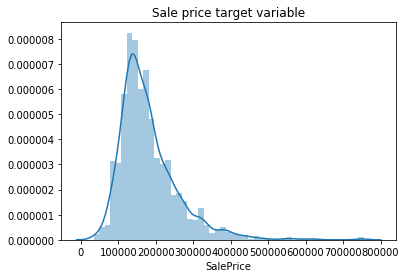

In [98]:
## Review Target variable 

sns.distplot(data_set.SalePrice)
plt.title("Sale price target variable")
plt.show()

In [99]:

# Data appeared to be having skewness for the better performence we will treate target variable to normalization 

data_set.SalePrice=np.log1p(data_set.SalePrice)

### 1. EDA

    - Noticed MasVnrType None Means actually NA for MasVnrType type
    - performing missing value analysis and treatment 
    - Analyse if we can impute null values
    - Univerent analysis
    - bivarient analysis with target variable


In [100]:
# Review the  NA's
data_set=data_set.replace("None",np.nan)

#missing value Treatment
_missing_values = pd.DataFrame(data_set.isna().sum(axis=0))
_missing_values.columns = ["NoOfMissingValues"]
_missing_values["Types"] =list(data_set.dtypes.values)


_missing_values["Per(%) Missinng"] =_missing_values.NoOfMissingValues / data_set.shape[0] * 100



_missing_values[_missing_values.NoOfMissingValues!= 0].sort_values("NoOfMissingValues",ascending = False)

,NoOfMissingValues,Types,Per(%) Missinng
PoolQC,1453,object,99.520548
MiscFeature,1406,object,96.301370
Alley,1369,object,93.767123
Fence,1179,object,80.753425
MasVnrType,872,object,59.726027
FireplaceQu,690,object,47.260274
LotFrontage,259,float64,17.739726
GarageType,81,object,5.547945
GarageYrBlt,81,float64,5.547945
GarageFinish,81,object,5.547945


In [101]:
# Review symetric missing values
_temp =data_set.loc[data_set.GarageType.isna(),["GarageType","GarageYrBlt","GarageFinish","GarageQual","GarageCond"]]
_temp1 =data_set.loc[data_set.BsmtExposure.isna(),["BsmtExposure","BsmtFinType2","BsmtFinType1","BsmtCond","BsmtQual"]]
_temp2 = data_set.loc[data_set.MasVnrArea.isna(),["MasVnrArea","MasVnrType"]]
_temp2 = data_set.loc[data_set.MasVnrType.isna(),["MasVnrArea","MasVnrType"]]

display(_temp.tail(),_temp1.tail(),_temp2.tail())

printmd("### Electrical dimentions")
print(data_set.Electrical.value_counts())

,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond
1349,NaN,NaN,NaN,NaN,NaN
1407,NaN,NaN,NaN,NaN,NaN
1449,NaN,NaN,NaN,NaN,NaN
1450,NaN,NaN,NaN,NaN,NaN
1453,NaN,NaN,NaN,NaN,NaN


,BsmtExposure,BsmtFinType2,BsmtFinType1,BsmtCond,BsmtQual
1216,NaN,NaN,NaN,NaN,NaN
1218,NaN,NaN,NaN,NaN,NaN
1232,NaN,NaN,NaN,NaN,NaN
1321,NaN,NaN,NaN,NaN,NaN
1412,NaN,NaN,NaN,NaN,NaN


,MasVnrArea,MasVnrType
1454,0.0,NaN
1455,0.0,NaN
1457,0.0,NaN
1458,0.0,NaN
1459,0.0,NaN


### Electrical dimentions

SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: Electrical, dtype: int64


##### Review comments

- reference to teh data description columns represents "PoolQC",  "MiscFeature","Alley","Fence" indicating no facilities like no pool found .. etc this can be billed with the no access or no prool etc and create dummy variables. however since 80% were missing even if we include these may create higher varience when we tried on unseen data <b> desided to remove instead of imputating </b>

- Id column indicating just serial number of the each observation not required to have this column

- FireplaceQu indicating that house does;t have fire place. we will ignore imputing this with No fireplace if we ignore inputing this all level dummy variables will be set to 1 as and when specific observation has specific level otherwise all level will be zero. so end result will be same.

- LotFrontage will be replaced with mediuan 

- <b> GarageType GarageYrBlt GarageFinish GarageQual GarageCond </b> Null indicating that property does't have Garage one option is to impute this with the No Garage however duplicatly we are going to create same features when we are doing one hot encoding insted of that  <b> preferable way is to do nothing in this stage and when we use pd.get_dummies this method will ignore creating dummies for NA variables </b>

- similar to the above BsmtExposure, BsmtFinType2,BsmtFinType1,BsmtCond,BsmtQual null indicating property does't have basement.

- with regards to the MasVnrArea and MasVnrType when na indicating that no Masonry veneer type, we are going to impute this with Not_Availible and MasVnrArea =0

- Electrical with the highest value

In [102]:
## Missing Value Treatment

# drop 4 variables since maximum number of observations were having NA
data_set=data_set.drop(["Id","PoolQC","MiscFeature","Alley","Fence"],axis=1)

#ingoring imputating missing values for FireplaceQu, 

#fileld with median distence 
data_set.LotFrontage=data_set.LotFrontage.fillna(data_set.LotFrontage.median())

#if GarageYr is not there in the  house by defualt GarageYrBlt will be empty. our through process of replacing with 2019 is work on derived field
data_set.GarageYrBlt=data_set.GarageYrBlt.fillna(data_set.GarageYrBlt.min()) 

# when Masonry veneer area is not availible in the house we will fill with zero
data_set.MasVnrArea = data_set.MasVnrArea.fillna(0)

#impute Electrical with the maximum occurences of SBrkr
data_set.Electrical = data_set.Electrical.fillna("SBrkr")

In [103]:
# Final Missing values
#missing value Treatment
_missing_values1 = pd.DataFrame(data_set.isna().sum(axis=0))
_missing_values1.columns = ["NoOfMissingValues"]
_missing_values1["Types"] =list(data_set.dtypes.values)


_missing_values1["Per(%) Missinng"] =_missing_values1.NoOfMissingValues / data_set.shape[0] * 100



_missing_values1[_missing_values1.NoOfMissingValues!= 0].sort_values("NoOfMissingValues",ascending = False)

,NoOfMissingValues,Types,Per(%) Missinng
MasVnrType,872,object,59.726027
FireplaceQu,690,object,47.260274
GarageType,81,object,5.547945
GarageFinish,81,object,5.547945
GarageQual,81,object,5.547945
GarageCond,81,object,5.547945
BsmtExposure,38,object,2.602740
BsmtFinType2,38,object,2.602740
BsmtQual,37,object,2.534247
BsmtCond,37,object,2.534247


### Review comments 

- Imputed all necessosry fields 
- only above stated fields were left without imputation as per data dictionary it is understand that above fields are NA because of no facilities were there in obsverations.
- when we create dummy variables for all cases by default get_dummies method will ignore these NA and filled with zero. ignoring this fields for imputation will help us to reduce number of duplicate representation.

### Univariate Analysis

- Perform 1st category field analysis and then numarical field analysis

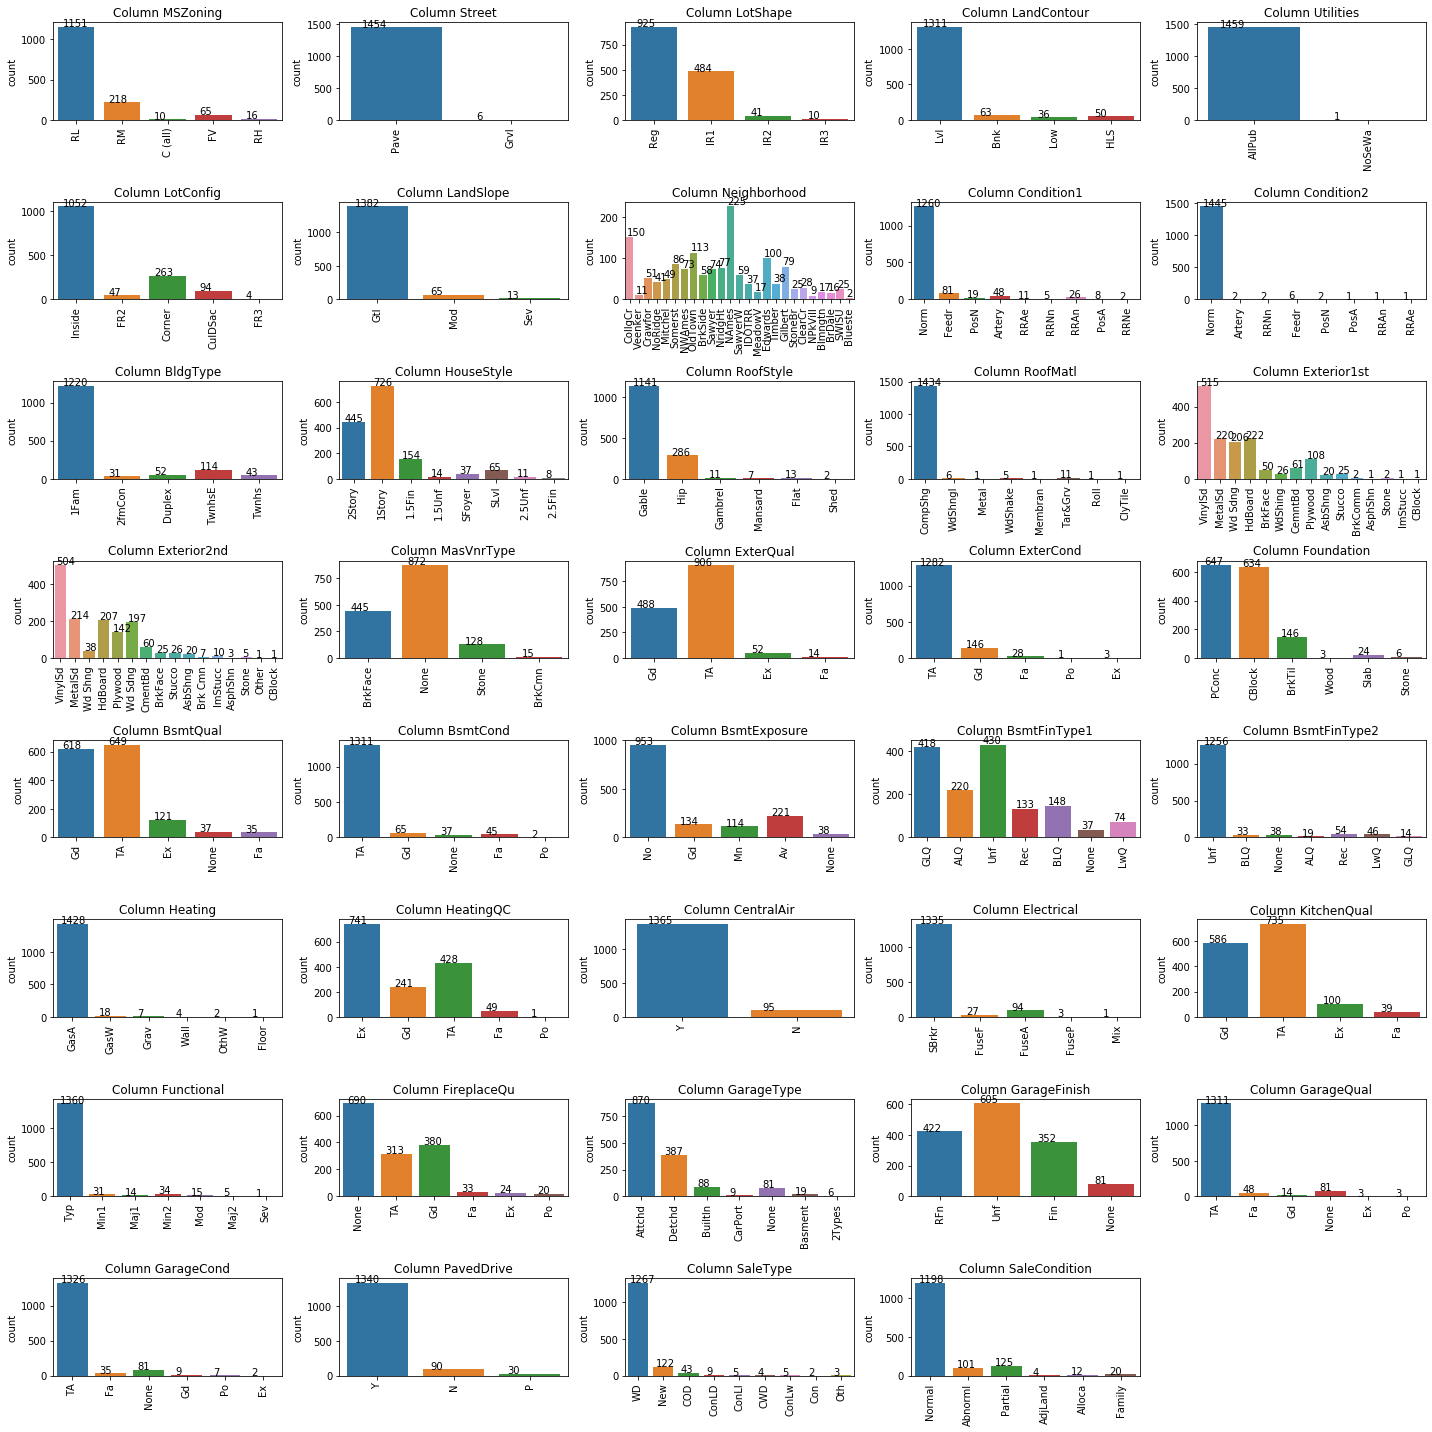

In [104]:
var_category_variables =data_set.select_dtypes(include=["object"]).columns
var_numerical_fields =data_set.select_dtypes(exclude =["object"]).columns



def display_categorical_distribution(col_name,ind):
    plt.subplot(8,5,ind)
    ax=sns.countplot(data_set[col_name].fillna("None"))
    plt.xlabel("")
    plt.xticks(rotation='vertical')
    plt.title(f"Column {col_name}")
    for p in ax.patches:
        ax.annotate('{00:}'.format(p.get_height()), (p.get_x()+0.1, p.get_height()+5))

    

plt.figure(figsize=(20,20))
for i in range(len(var_category_variables)):
    display_categorical_distribution(var_category_variables[i],i+1)
plt.tight_layout(h_pad=1, w_pad=1)

### Review summary 

- By seaing the above category graphs we can see clearly some categories are dominated by teh laragly single level of category. any variables indicating of having same values will mot adding any value on explaining our target variable hence is desided to further evaluate each category comparing with the highest level vs others levels

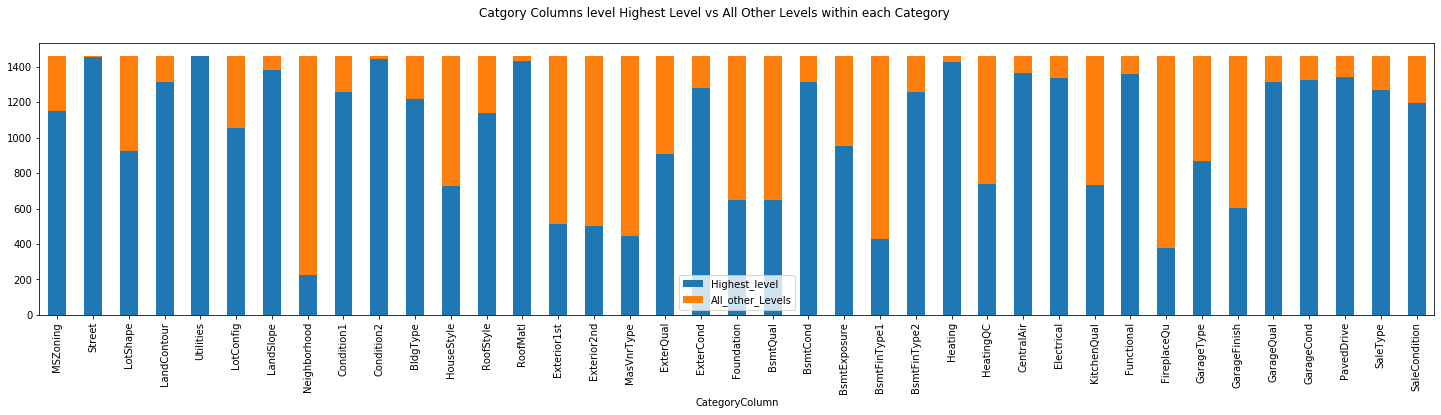

### Category column single level exlaining over 80% of column

,Highest_level,All_other_Levels,Dominent_level_per
CategoryColumn,,,
Street,1454,6,99.59
LandContour,1311,149,89.79
Utilities,1459,1,99.93
LandSlope,1382,78,94.66
Condition1,1260,200,86.30
Condition2,1445,15,98.97
BldgType,1220,240,83.56
RoofMatl,1434,26,98.22
ExterCond,1282,178,87.81


In [67]:
_lst_category_level_highest_vs_others = pd.DataFrame()

for i in var_category_variables:
    high_level = sorted(data_set[i].value_counts(),reverse=True)[0]
    others_levels = data_set.shape[0]-high_level
    _dict={"CategoryColumn":i,"Highest_level": high_level,"All_other_Levels":others_levels}
    _temp = pd.DataFrame(_dict,index=[0])
    if(_lst_category_level_highest_vs_others.shape[0] ==0):
        _lst_category_level_highest_vs_others = _temp
    else:
        _lst_category_level_highest_vs_others = pd.concat([_lst_category_level_highest_vs_others,_temp])


_lst_category_level_highest_vs_others=_lst_category_level_highest_vs_others.set_index("CategoryColumn")
_lst_category_level_highest_vs_others.plot(kind="bar",stacked=True,figsize=(25,5))
plt.suptitle("Catgory Columns level Highest Level vs All Other Levels within each Category")
plt.show()

printmd("### Category column single level exlaining over 80% of column")

_lst_category_level_highest_vs_others["Dominent_level_per"] = round(_lst_category_level_highest_vs_others.Highest_level / (data_set.shape[0])*100,2)

_lst_category_level_highest_vs_others[_lst_category_level_highest_vs_others.Dominent_level_per >80]

### Review Summary

- Above table and Graph explaining that category field is majorly dominent by the singular level
- Ultimatly this can be treated as as good as Null since 90% of values were explained by the singler level. hence it is desided to remove categorical columns where the data is having 80% of single levels

In [105]:
## Delete Domninent fields (majorly having singular values)

_tobe_deleted = list(_lst_category_level_highest_vs_others[_lst_category_level_highest_vs_others.Dominent_level_per >90].index)
data_set=data_set.drop(_tobe_deleted,axis=1)

### Review Numeric fields

    

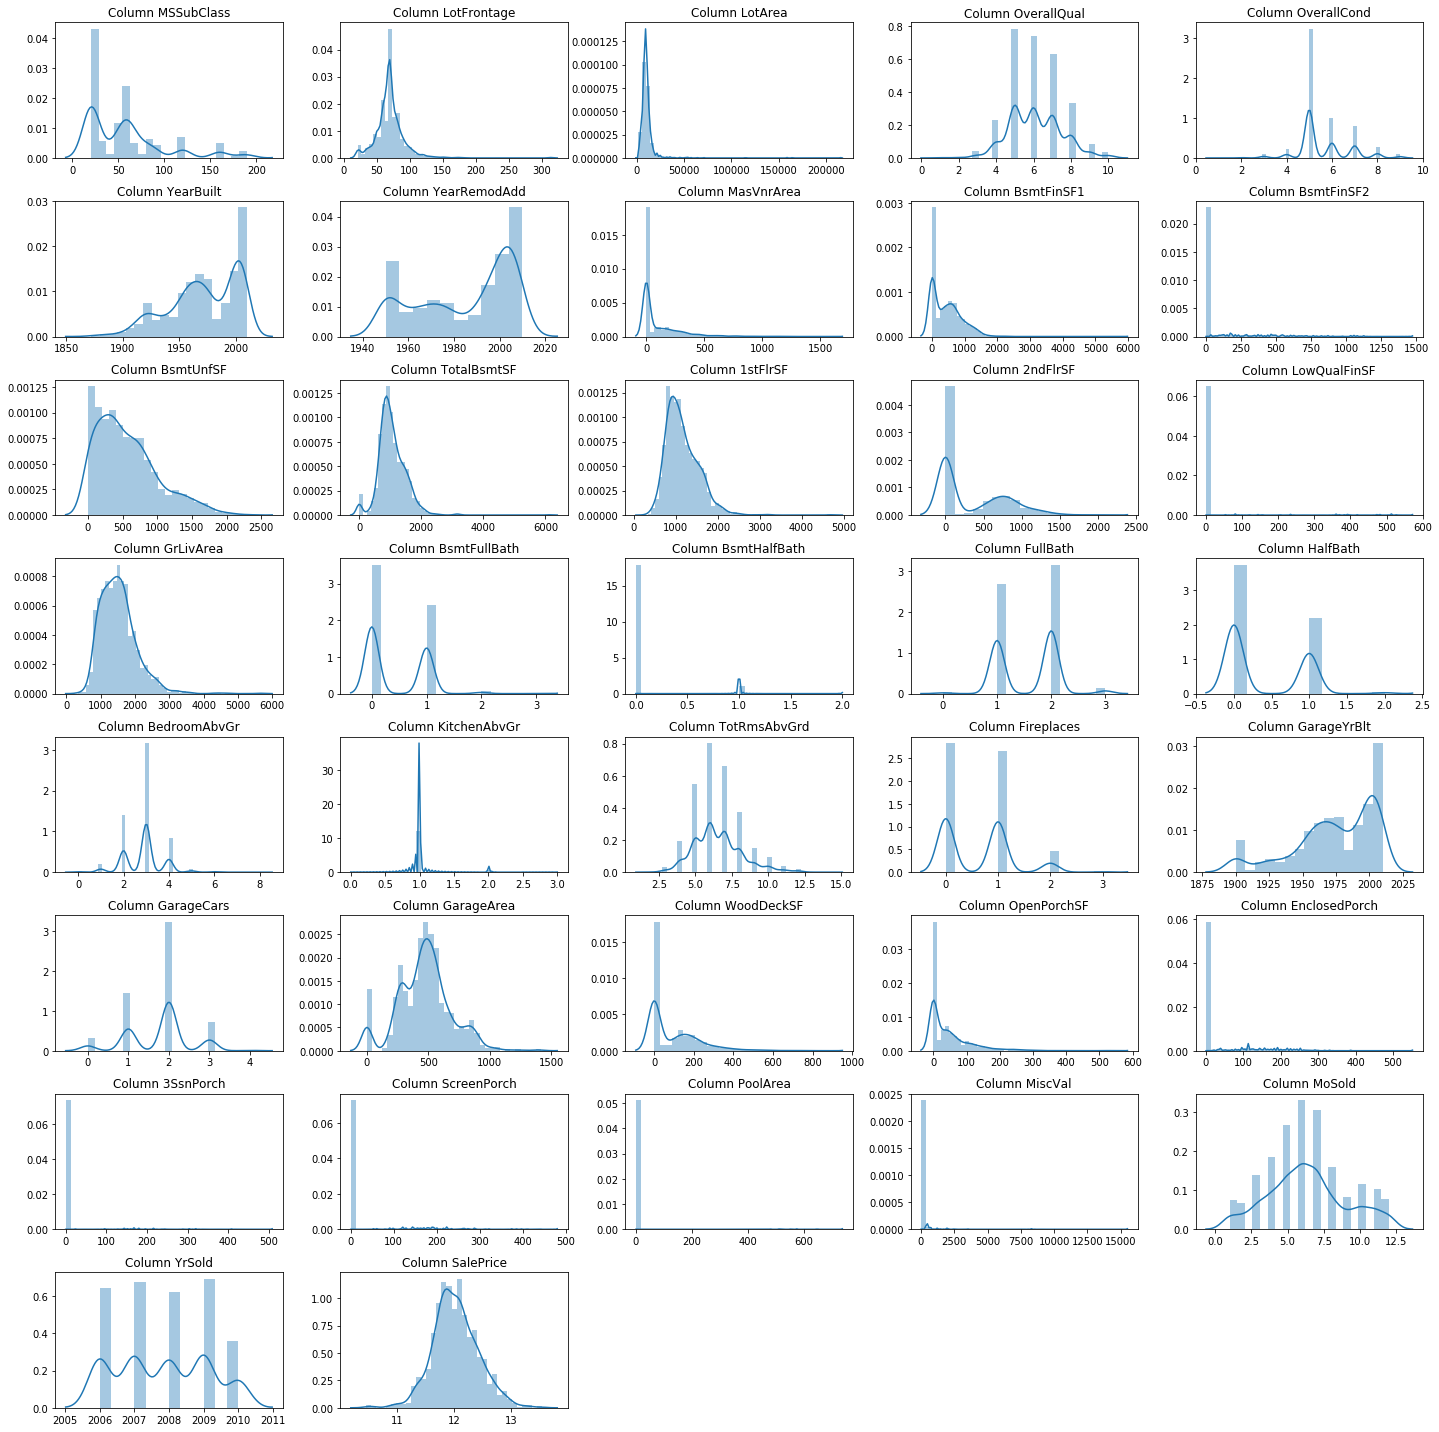

In [106]:
# Review Numeric fields

def display_Numerical_distribution(col_name,ind):
    plt.subplot(8,5,ind)
    ax=sns.distplot(data_set[col_name].fillna("0"))
    plt.xlabel("")
    plt.title(f"Column {col_name}")
    
    

plt.figure(figsize=(20,20))
for i in range(len(var_numerical_fields)):
    display_Numerical_distribution(var_numerical_fields[i],i+1)
plt.tight_layout(h_pad=1, w_pad=1)

### Review Summary

- <font color ="brown"><b>MSSubClass,OverallQual,OverallCond</b></font> are actually categorical columns these fields type need to be changed to object type
- <font color="black"><b>LotFrontage,LotArea</b></font> indicating outliers in the data this need to be adjusted
- <font color ="green"><b>YearBuilt,YearRemodAdd,GarageYrBlt,YrSold</b></font> it is in the form of year insted of we can connvert to the age of property
- BsmtFinSF1, BsmtFinSF2, BsmtUnfSF seams explained in one field TotalBsmtSF will see how the explain target variables
- LowQualFinSF seems major number of houses were classifed as 0 will see how the model will evaluate
- <font color ="brown"><b>BsmtFullBath,BsmtHalfBath,FullBath,HalfBath</b></font> are seems indicating number of bathrooms these can be treated as category insted of numarical fields
- BedroomAbvGr indicating that major number of houses are with 0,1,2,3,4 and few expetional houses indicating high number of houses. these can be adjusted to 4 and create category column insted of neumaric columns
- TotRmsAbvGrd is actually categorical columns 
- Fireplaces is also indicating as categorical columns
- GarageCars is indicating categorical column 
- MoSold can be droped since it is month name 

### Review Revision-2 

- <b>Initially coverted all ordered number from Numerical to categorical and despite of creating number of extra features results are not improved. hence tried with as is considered as Numerical variables since there are order is assosiated.</b>
- <b>resulting of above number of features were drastically reduced and at the same performence is improved drastically hence it is recomended to go with by considering Numerical Ordered values as simmple Numerical fields</b>


In [173]:
data_set.columns[pd.Series(data_set.columns).str.contains("SF", regex=False)]



Index(['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF',
       '2ndFlrSF', 'LowQualFinSF', 'WoodDeckSF', 'OpenPorchSF'],
      dtype='object')

In [176]:
## Cleaning numerical fields 
data_set_stage1 = data_set.copy()

# convert date of year to age which will help us to infrenceing and model development easy
data_set_stage1[["AgeBuilt","AgeRemodAdd","GarageAgeBlt","AgeSold"]]=2019-data_set_stage1[["YearBuilt","YearRemodAdd","GarageYrBlt","YrSold"]]
data_set_stage1=data_set_stage1.drop(["YearBuilt","YearRemodAdd","GarageYrBlt","YrSold"],axis=1)

#Derived Bath rooms
data_set_stage1["BathRooms"]= data_set_stage1.BsmtFullBath.fillna(0) + data_set_stage1.BsmtHalfBath.fillna(0) *0.5 +data_set_stage1.FullBath.fillna(0) +data_set_stage1.HalfBath.fillna(0) *0.5

data_set_stage1["TotalSF"]= data_set_stage1.BsmtFinSF1.fillna(0) + data_set_stage1.BsmtFinSF2.fillna(0) +data_set_stage1.BsmtUnfSF.fillna(1) +data_set_stage1["1stFlrSF"].fillna(0)+data_set_stage1["2ndFlrSF"].fillna(0)  +data_set_stage1.LowQualFinSF.fillna(0) + data_set_stage1.WoodDeckSF.fillna(0) +data_set_stage1.OpenPorchSF.fillna(0)


#convert to categorical variables (Review 2 changes)
#data_set_stage1[["MSSubClass","OverallQual","OverallCond"]]=data_set_stage1[["MSSubClass","OverallQual","OverallCond"]].astype(object)
data_set_stage1[["MSSubClass"]]=data_set_stage1[["MSSubClass"]].astype(object)

#droping since maxmum number of observations are having zero columns 
data_set_stage1=data_set_stage1.drop("LowQualFinSF",axis=1)
                                     
#data_set_stage1[["BsmtFullBath","BsmtHalfBath","FullBath","HalfBath"]]=data_set_stage1[["BsmtFullBath","BsmtHalfBath","FullBath","HalfBath"]].astype(object)

#uploading if bedrooms over 6 to 4 because over 6 is very insginificant number of houses
#data_set_stage1.BedroomAbvGr = [4 if i>=4 else i for i in data_set_stage1.BedroomAbvGr ]

#data_set_stage1.BedroomAbvGr =  data_set_stage1.BedroomAbvGr.astype(object)

#convert to categorical variables 
#data_set_stage1[["TotRmsAbvGrd","Fireplaces","GarageCars"]]= data_set_stage1[["TotRmsAbvGrd","Fireplaces","GarageCars"]].astype(object)

#data is majorly belongs to one level which indicating no use 
# and also deleting month of sold, since we obtain sold age of property
data_set_stage1=data_set_stage1.drop(["EnclosedPorch","3SsnPorch","ScreenPorch","PoolArea","MiscVal","MoSold"],axis=1)


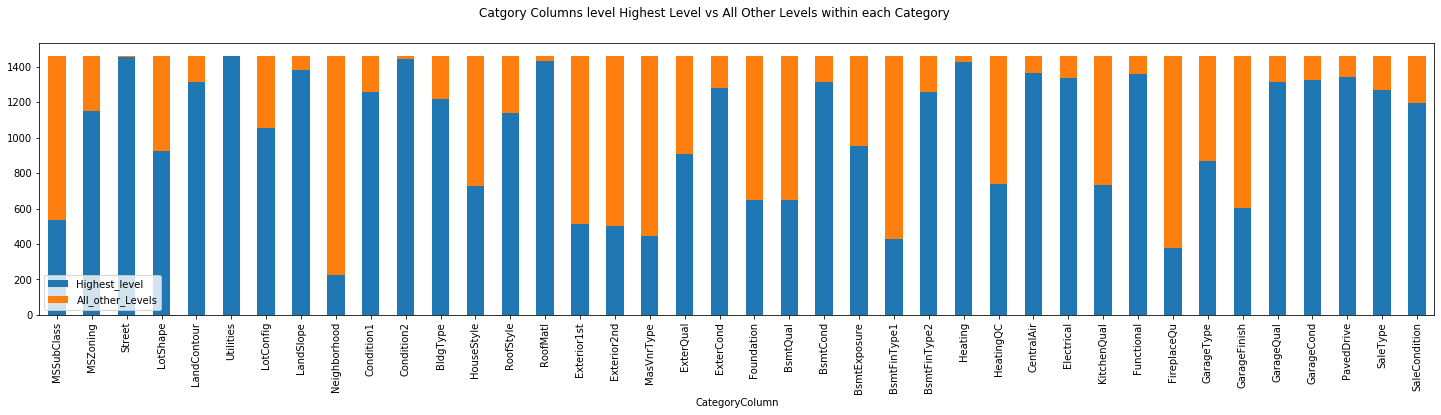

### Category column single level exlaining over 80% of column

,Highest_level,All_other_Levels,Dominent_level_per
CategoryColumn,,,
Street,1454,6,99.59
LandContour,1311,149,89.79
Utilities,1459,1,99.93
LandSlope,1382,78,94.66
Condition1,1260,200,86.30
Condition2,1445,15,98.97
BldgType,1220,240,83.56
RoofMatl,1434,26,98.22
ExterCond,1282,178,87.81


In [177]:
# Review categorical Level comparision between Dominent Level vs Others.
var_category_variables =  list(data_set_stage1.select_dtypes(include=["object"]).columns)
_lst_category_level_highest_vs_others = pd.DataFrame()

for i in var_category_variables:
    high_level = sorted(data_set_stage1[i].value_counts(),reverse=True)[0]
    others_levels = data_set_stage1.shape[0]-high_level
    _dict={"CategoryColumn":i,"Highest_level": high_level,"All_other_Levels":others_levels}
    _temp = pd.DataFrame(_dict,index=[0])
    if(_lst_category_level_highest_vs_others.shape[0] ==0):
        _lst_category_level_highest_vs_others = _temp
    else:
        _lst_category_level_highest_vs_others = pd.concat([_lst_category_level_highest_vs_others,_temp])


_lst_category_level_highest_vs_others=_lst_category_level_highest_vs_others.set_index("CategoryColumn")
_lst_category_level_highest_vs_others.plot(kind="bar",stacked=True,figsize=(25,5))
plt.suptitle("Catgory Columns level Highest Level vs All Other Levels within each Category")
plt.show()

printmd("### Category column single level exlaining over 80% of column")

_lst_category_level_highest_vs_others["Dominent_level_per"] = round(_lst_category_level_highest_vs_others.Highest_level / (data_set_stage1.shape[0])*100,2)

_lst_category_level_highest_vs_others[_lst_category_level_highest_vs_others.Dominent_level_per >80]

#### Review Remaks 

- above list of tables indicating that major number of obsevations were having either one level. it is can be treated that as good as like same value for entrire obsevation.
- since these categories are not going to explain the varience we will remove these fields over 80% dominence



In [178]:
# Deleting categorical variables where highly dominent by the singular level

data_set_stage1=data_set_stage1.drop(_lst_category_level_highest_vs_others[_lst_category_level_highest_vs_others.Dominent_level_per >90].index,axis=1)

### Bivariate analysis with the target variables 

- understand the numarical correlations 
- understand the categorical field with the target variable

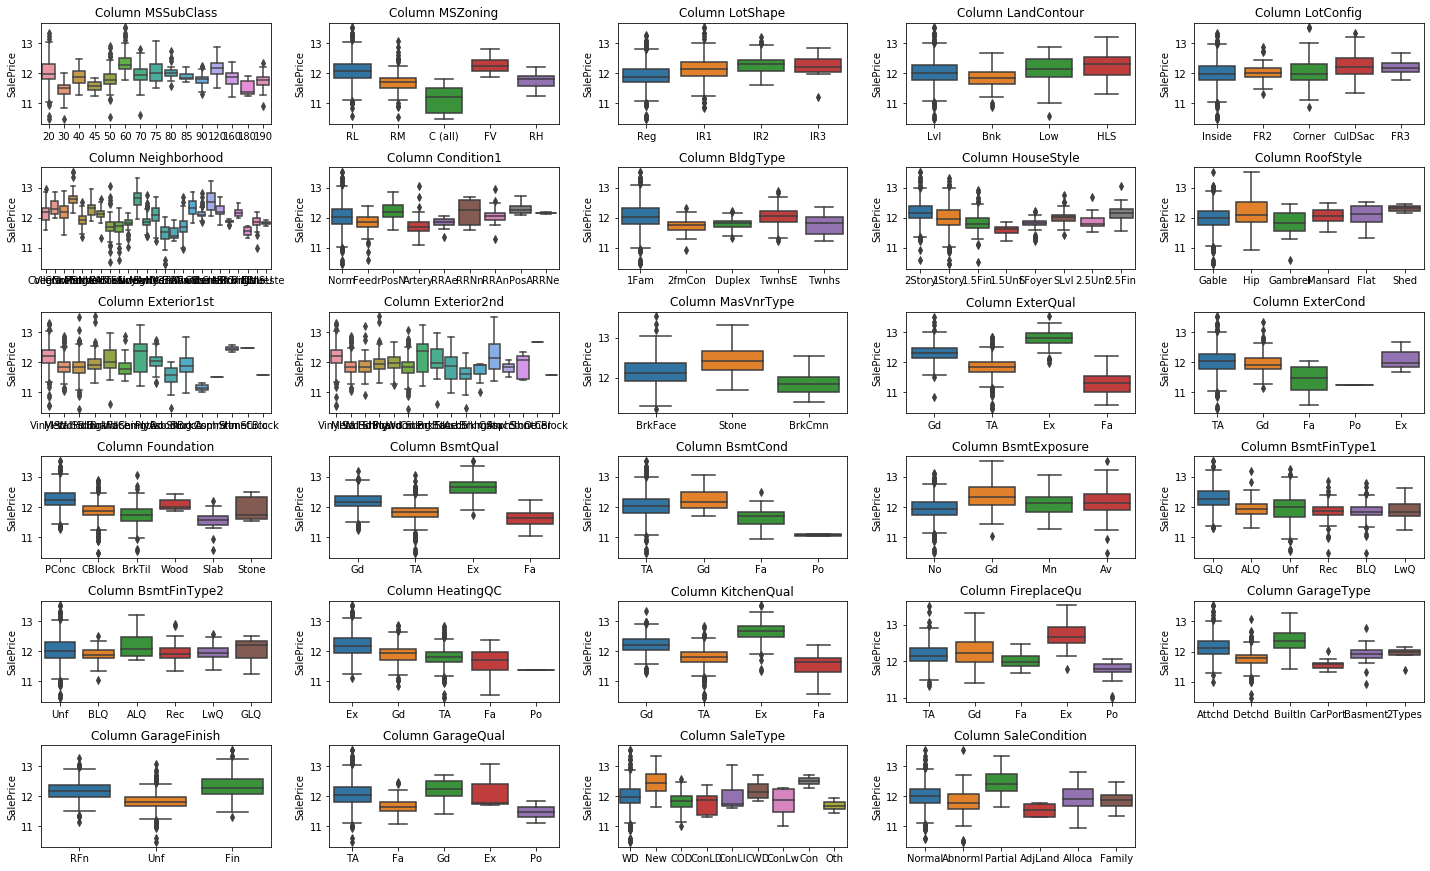

In [179]:
# Categorical Variable Correlation with Target Variable

#obtain numerical fields 
var_categorical_fields =list(data_set_stage1.select_dtypes(include=["object"]).columns)

def display_Categorical_distribution(col_name,ind):
    plt.subplot(10,5,ind)
    #ax=sns.distplot(data_set_stage1[col_name].fillna("0"))
    sns.boxplot(x=col_name,y="SalePrice",data =data_set_stage1)
    plt.xlabel("")
    plt.title(f"Column {col_name}")    
    

plt.figure(figsize=(20,20))
for i in range(len(var_categorical_fields)):
    display_Categorical_distribution(var_categorical_fields[i],i+1)
plt.tight_layout(h_pad=1, w_pad=1)

## Review Summary

- Neighborhood indicating higher levels
- BsmtFullBath not indicating any corelation with target variable
- remaining all categories indicating some variation with the target varibale. hence it is desided to remove <b>BsmtFullBath</b> for the model building

In [180]:
# deleting BsmtFullBath since not indicating any varience 
#data_set_stage1=data_set_stage1.drop("BsmtFullBath",axis=1)

#deleting following variables which are not indicating any differences 
data_set_stage1=data_set_stage1.drop(["LotShape","LotConfig","RoofStyle","BsmtExposure","GarageFinish"],axis=1)

# Review of numarical fields with target variable 

- correlation graph
- scattor plot

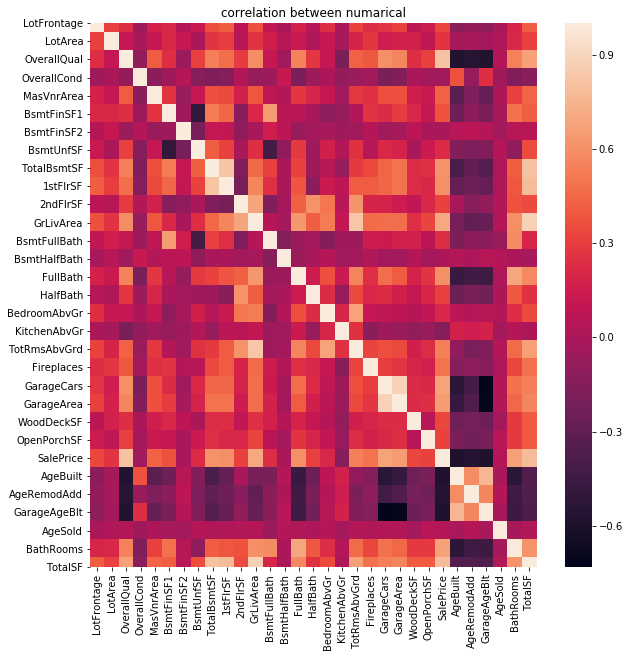

#### Higher stronger correlation with target variable

GarageAgeBlt   -0.594179
AgeBuilt       -0.586570
AgeRemodAdd    -0.565608
KitchenAbvGr   -0.147548
OverallCond    -0.036868
BsmtHalfBath   -0.005149
BsmtFinSF2      0.004832
AgeSold         0.037263
BedroomAbvGr    0.209043
BsmtUnfSF       0.221985
BsmtFullBath    0.236224
LotArea         0.257320
HalfBath        0.313982
2ndFlrSF        0.319300
OpenPorchSF     0.321053
WoodDeckSF      0.334135
LotFrontage     0.335292
BsmtFinSF1      0.372023
MasVnrArea      0.426776
Fireplaces      0.489450
TotRmsAbvGrd    0.534422
FullBath        0.594771
1stFlrSF        0.596981
TotalBsmtSF     0.612134
GarageArea      0.650888
BathRooms       0.673011
GarageCars      0.680625
GrLivArea       0.700927
TotalSF         0.785171
OverallQual     0.817185
SalePrice       1.000000
Name: SalePrice, dtype: float64

In [181]:
# obtaing var_numarical_fields
var_numarical_fields =list(data_set_stage1.select_dtypes(exclude=["object"]).columns)

corr=data_set_stage1[var_numarical_fields].corr()

plt.figure(figsize=(10,10))
sns.heatmap(corr)
plt.title("correlation between numarical")
plt.show()

printmd("#### Higher stronger correlation with target variable")
display(corr["SalePrice"].sort_values())

### Review Remaks

- Price of property is indicating highly -ve correlated with Age of Built and Age of remod and indicating high +ve with the GrLiveArea Size, GarageArea
- however above correlation map also indicating that high correlation between dependent variables. this may be lead to the multi colnarity problems.

### Approches 

- create dummy variables for categorical columns 
- split data train and test 
- treating outliers
- scaling the numarical data
- model building with the training data
- optmize the model hyper parameters
- evaluate model performence on the test data 


In [182]:
data_set_stage2 = data_set_stage1.copy()

# Cration of Dummy variables 
var_numarical_fields = list( data_set_stage2.select_dtypes(exclude=["object"]).columns)
var_categorical_fields  = list( data_set_stage2.select_dtypes(include=["object"]).columns) 

#treating outliers
def reset_bounderies(column_name):
    _temp_percet = data_set_stage2[column_name].quantile([0.01,0.99]).values
    data_set_stage2[column_name]=data_set_stage2[column_name].apply(lambda x:  _temp_percet[0] if x < _temp_percet[0] else x )
    data_set_stage2[column_name]=data_set_stage2[column_name].apply(lambda x:  _temp_percet[1] if x > _temp_percet[1] else x )
    

# apply boundery treatment for each columns
for i in var_numarical_fields:
    reset_bounderies(i)

var_numarical_fields.remove('SalePrice')

#one hot encoding for categorical fields 
_temp_dummies_set=pd.get_dummies(data_set_stage2[var_categorical_fields])
data_set_stage2=pd.concat([data_set_stage2,_temp_dummies_set],axis=1)
data_set_stage2=data_set_stage2.drop(var_categorical_fields,axis=1)

# train and test data
train_data,test_data=train_test_split(data_set_stage2,test_size=0.30, random_state=40)

printmd(f"### Shape of Train Data Set {train_data.shape}")
printmd(f"### Shape of Test Data Set {test_data.shape}")

X_train = train_data.copy()
y_train = pd.DataFrame(X_train.pop("SalePrice"))

X_test = test_data.copy()
y_test = pd.DataFrame(X_test.pop("SalePrice"))

#scaling training_data
scaler = StandardScaler()
X_train[var_numarical_fields]=scaler.fit_transform(X_train[var_numarical_fields])
X_test[var_numarical_fields]=scaler.transform(X_test[var_numarical_fields])

scaler_target = StandardScaler()
y_train["SalePrice"]=scaler_target.fit_transform(y_train)
y_test["SalePrice"]=scaler_target.transform(y_test)

### Shape of Train Data Set (1022, 211)

### Shape of Test Data Set (438, 211)



## Experementing Vanilla  Linear Regression 

- try with LinearRegression with the combination of N Features to look into sufficent features

Fitting 5 folds for each of 50 candidates, totalling 250 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   58.1s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:  3.0min
[Parallel(n_jobs=-1)]: Done 250 out of 250 | elapsed:  3.6min finished


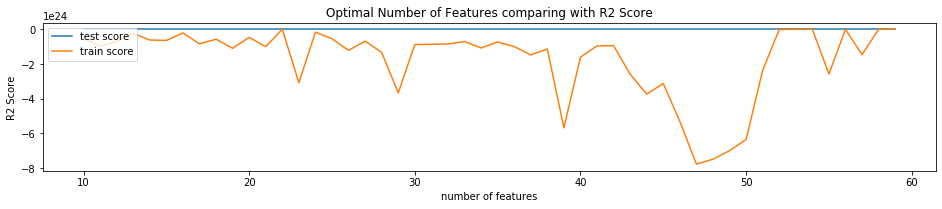

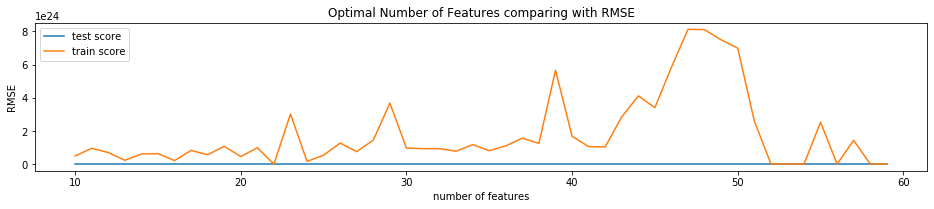

In [183]:
# identify the best n number of features and trying with linear regression 

param_grid = {'n_features_to_select': list(range(10, 60))}

lm = LinearRegression()
rfe =RFE(lm)

# cross validation
folds = 5
#scoring = {'r2_score': make_scorer(r2_score), 'RMSE': "neg_mean_squared_error"}
scoring = {'r2_score': "r2", 'RMSE': make_scorer(mean_squared_error)}
model_cv = GridSearchCV(estimator = rfe, 
                        param_grid = param_grid, 
                        #scoring= "neg_mean_absolute_error", 
                        scoring= scoring, 
                        cv = folds, 
                        return_train_score=True,
                        refit  = "r2_score",
                        verbose = 1,n_jobs=-1)            
model_cv.fit(X_train, y_train) 


cv_results = pd.DataFrame(model_cv.cv_results_)
plt.figure(figsize=(16,6))
plt.subplot(2,1,1)
plt.plot(cv_results["param_n_features_to_select"], cv_results["mean_train_r2_score"])
plt.plot(cv_results["param_n_features_to_select"], cv_results["mean_test_r2_score"])
plt.xlabel('number of features')
plt.ylabel('R2 Score')
plt.title("Optimal Number of Features comparing with R2 Score")
plt.legend(['test score', 'train score'], loc='upper left')

plt.figure(figsize=(16,6))
plt.subplot(2,1,2)
plt.plot(cv_results["param_n_features_to_select"], cv_results["mean_train_RMSE"])
plt.plot(cv_results["param_n_features_to_select"], cv_results["mean_test_RMSE"])
plt.xlabel('number of features')
plt.ylabel('RMSE')
plt.title("Optimal Number of Features comparing with RMSE")
plt.legend(['test score', 'train score'], loc='upper left')
plt.show()

### Review summary 

- vanilla regression indicating that along with the n number of features changes model is very unstable and no clear indication of how this will change along with the N features
- some time it is also demoted R2 Squere entered into the -ve which means that there is possibility of over fitting.
- however when the number of features were either lesser than 20 or high as 60 indicating that some what near close to test score.

### Perform Both Ridge and Lass for different number of features for to deside how the model will fit

### Evaluating Model : Ridge and Number of features 210

{'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50, 100]}
Fitting 30 folds for each of 26 candidates, totalling 780 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:   33.8s
[Parallel(n_jobs=-1)]: Done 341 tasks      | elapsed:   38.5s
[Parallel(n_jobs=-1)]: Done 773 out of 780 | elapsed:   45.4s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done 780 out of 780 | elapsed:   45.5s finished


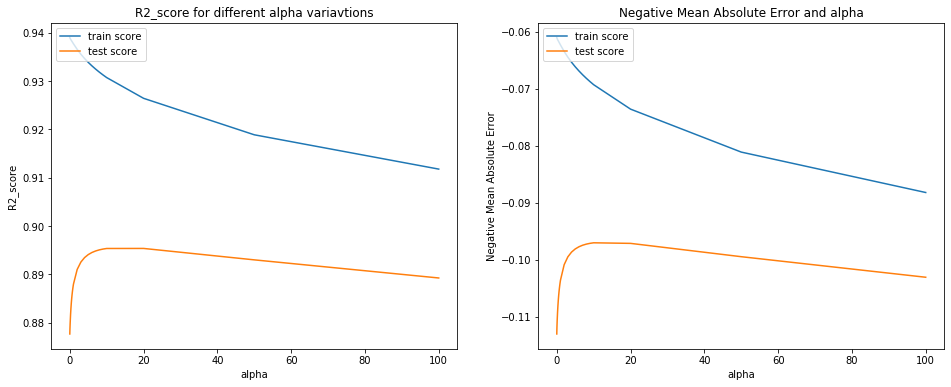

### Evaluating Model : Ridge and Number of features 100

{'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50, 100]}
Fitting 30 folds for each of 26 candidates, totalling 780 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done 348 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 780 out of 780 | elapsed:    6.5s finished


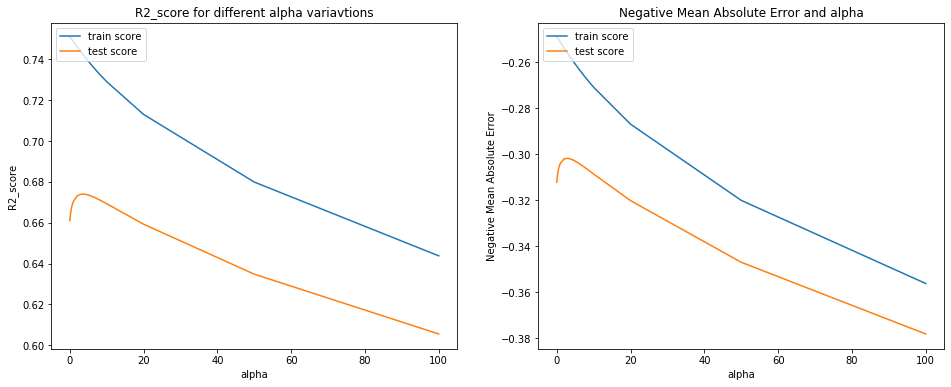

### Evaluating Model : Ridge and Number of features 50

{'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50, 100]}
Fitting 30 folds for each of 26 candidates, totalling 780 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done 348 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 780 out of 780 | elapsed:    4.8s finished


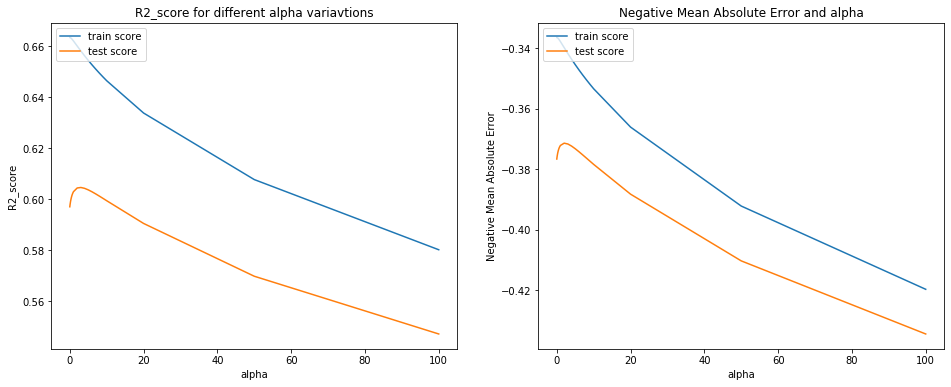

### Evaluating Model : Ridge and Number of features 30

{'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50, 100]}
Fitting 30 folds for each of 26 candidates, totalling 780 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done 416 tasks      | elapsed:    2.7s
[Parallel(n_jobs=-1)]: Done 780 out of 780 | elapsed:    4.8s finished


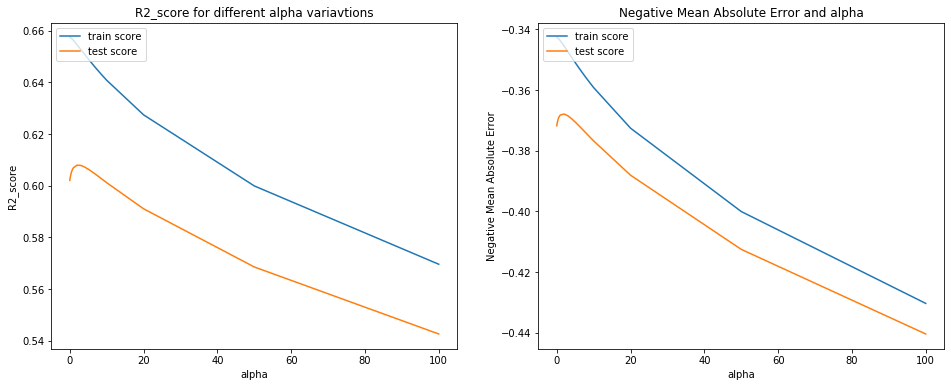

### Evaluating Model : Ridge and Number of features 10

{'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 20, 50, 100]}
Fitting 30 folds for each of 26 candidates, totalling 780 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done 552 tasks      | elapsed:    3.6s
[Parallel(n_jobs=-1)]: Done 780 out of 780 | elapsed:    5.0s finished


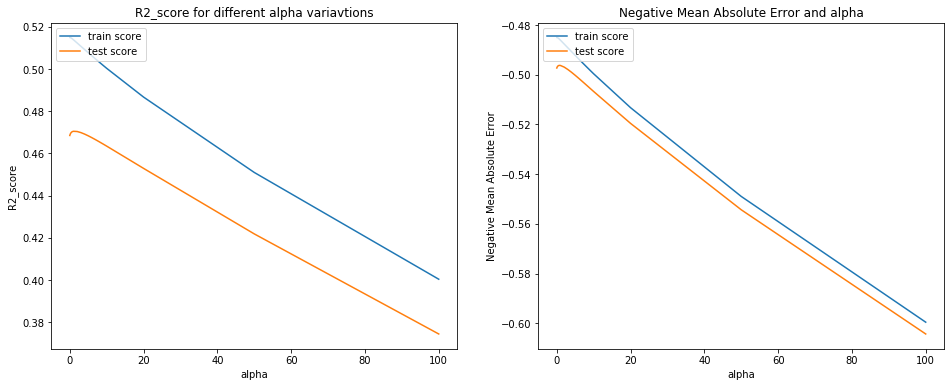

### Evaluating Model : Lasso and Number of features 210

{'alpha': [1e-40, 1e-30, 1e-20, 1e-25, 1e-10, 1e-08, 1e-05, 0.0001, 0.001, 0.01]}
Fitting 30 folds for each of 10 candidates, totalling 300 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    6.8s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:   30.3s
[Parallel(n_jobs=-1)]: Done 293 out of 300 | elapsed:   40.2s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   40.3s finished


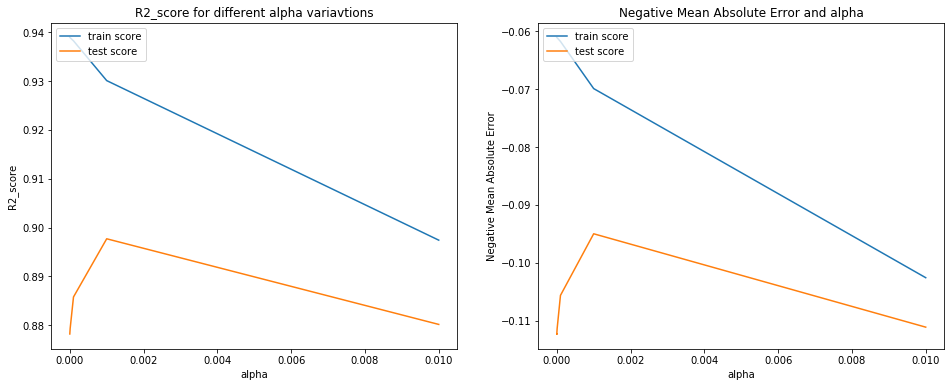

### Evaluating Model : Lasso and Number of features 100

{'alpha': [1e-40, 1e-30, 1e-20, 1e-25, 1e-10, 1e-08, 1e-05, 0.0001, 0.001, 0.01]}
Fitting 30 folds for each of 10 candidates, totalling 300 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:   14.8s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   18.3s finished


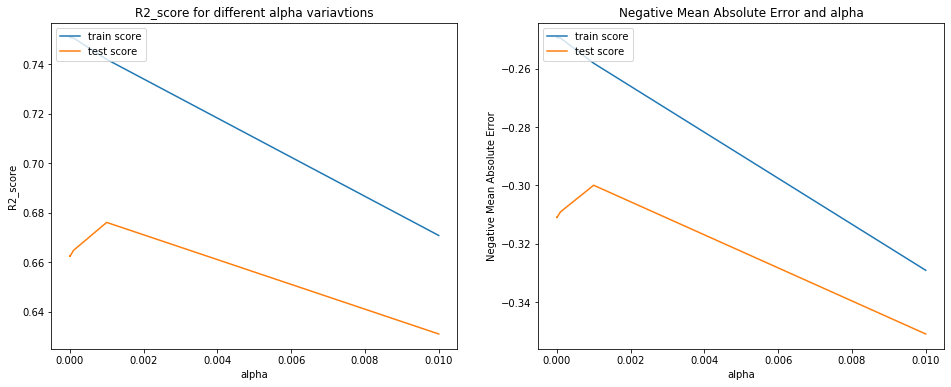

### Evaluating Model : Lasso and Number of features 50

{'alpha': [1e-40, 1e-30, 1e-20, 1e-25, 1e-10, 1e-08, 1e-05, 0.0001, 0.001, 0.01]}
Fitting 30 folds for each of 10 candidates, totalling 300 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  76 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    9.0s finished


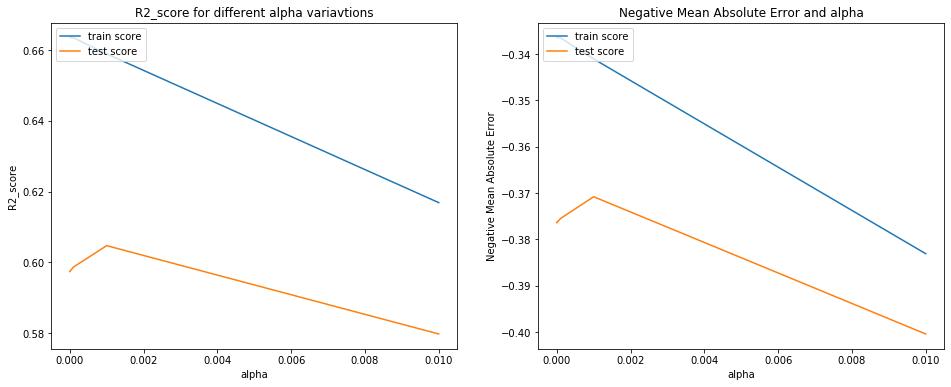

### Evaluating Model : Lasso and Number of features 30

{'alpha': [1e-40, 1e-30, 1e-20, 1e-25, 1e-10, 1e-08, 1e-05, 0.0001, 0.001, 0.01]}
Fitting 30 folds for each of 10 candidates, totalling 300 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  76 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    5.2s finished


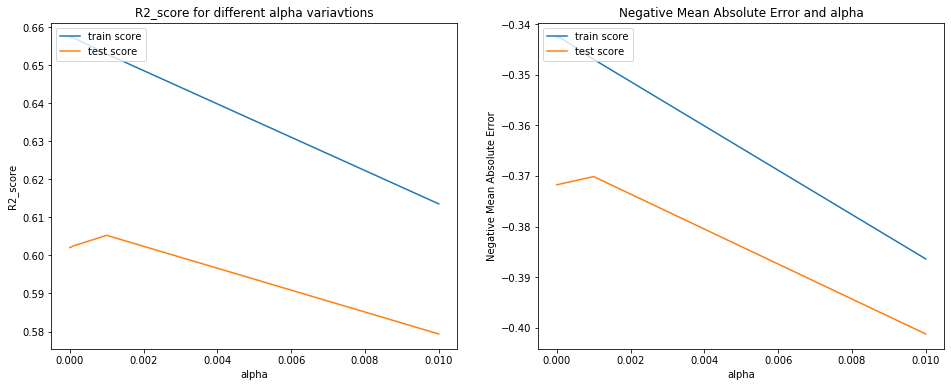

### Evaluating Model : Lasso and Number of features 10

{'alpha': [1e-40, 1e-30, 1e-20, 1e-25, 1e-10, 1e-08, 1e-05, 0.0001, 0.001, 0.01]}
Fitting 30 folds for each of 10 candidates, totalling 300 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:    2.6s finished


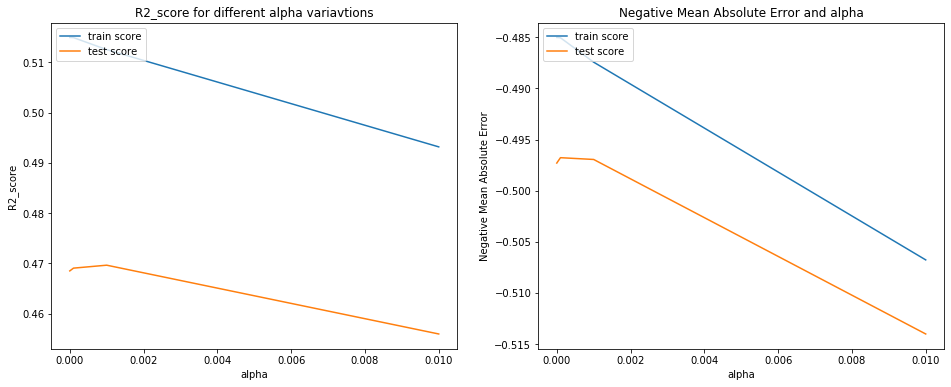

In [184]:

def experment_Ridge(n_features_to_select,model):
    
    lm =LinearRegression()
    rfe=RFE(lm,n_features_to_select =n_features_to_select)
    rfe.fit(X_train,y_train)

    #list(zip(X_train.columns,rfe.support_,rfe.ranking_)) 
    selected_columns = list(X_train.columns[rfe.support_])
    #selected_columns=var_numarical_fields
    
    printmd(f"### Evaluating Model : {model} and Number of features {n_features_to_select}" )
    #param_grid = {'estimator__alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4,0.5]}
    param_grid = {'alpha': [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 2.0, 3.0, 
                            4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0,20,50,100]}
        
    #param_grid = {'alpha': list(np.linspace(start = 0, stop = 100, num = 100))}
    if(model =="Ridge"):
        lm = Ridge()
        #param_grid = {'alpha': list(np.linspace(start = 0, stop = 10, num = 20))}
    else:
        lm= Lasso()
        param_grid = {'alpha': [1e-40,1e-30,1e-20,1e-25, 1e-10, 1e-8, 1e-5,1e-4, 1e-3,1e-2]}
        
    
    
    print(param_grid)
# cross validation
    folds = 30
    scoring = {'r2_score': make_scorer(r2_score), 'RMSE': "neg_mean_squared_error"}
    model_cv = GridSearchCV(estimator = lm, 
                        param_grid = param_grid, 
                        #scoring= "neg_mean_absolute_error", 
                        scoring= scoring, 
                        cv = folds, 
                        return_train_score=True,
                        refit  = "r2_score",
                        verbose = 1,n_jobs=-1)            
    model_cv.fit(X_train[selected_columns], y_train) 
    cv_results = pd.DataFrame(model_cv.cv_results_)
    cv_results.head()
    cv_results['param_alpha'] = cv_results['param_alpha']

    # plotting
    plt.figure(figsize=(16,6))
    plt.subplot(1,2,1)
    plt.plot(cv_results['param_alpha'], cv_results['mean_train_r2_score'])
    plt.plot(cv_results['param_alpha'], cv_results['mean_test_r2_score'])
    plt.xlabel('alpha')
    plt.ylabel('R2_score')
    plt.title("R2_score for different alpha variavtions")
    plt.legend(['train score', 'test score'], loc='upper left')
    
    plt.subplot(1,2,2)
    plt.plot(cv_results['param_alpha'], cv_results['mean_train_RMSE'])
    plt.plot(cv_results['param_alpha'], cv_results['mean_test_RMSE'])
    plt.xlabel('alpha')
    plt.ylabel('Negative Mean Absolute Error')
    plt.title("Negative Mean Absolute Error and alpha")
    plt.legend(['train score', 'test score'], loc='upper left')
    
    
    
    plt.show()
    

    
# performence of Ridge 
experment_Ridge(X_train.shape[1],"Ridge")
experment_Ridge(100,"Ridge")
experment_Ridge(50,"Ridge")
experment_Ridge(30,"Ridge")
experment_Ridge(10,"Ridge")


# performence of Lasso
experment_Ridge(X_train.shape[1],"Lasso")
experment_Ridge(100,"Lasso")
experment_Ridge(50,"Lasso")
experment_Ridge(30,"Lasso")
experment_Ridge(10,"Lasso")


### Review Summary

#### Ridge Regession 

- identified that when the number of features were fully selected model performence is very high i.e above <b> 0.91 as training score and 0.87 test score with the alpha =5 </b>. and when alpha either above 5 or below 5 indicating higher vareince comparing with the test data set.
- <b> Performence of the model went down along with the number of features when the number of features were reduced at the variaous values (100,50,30 and 10) dispite of having alpha at the same level of 5 model R2 score and Mean absolute error scores were indicating major correction </b>. 
- in thid case it is better approch to consider all parameters into the model  


#### Lasso Regression

- similar to the Ridge regressioin Lass also indicating same behaiour with the number of features. when the  number of features were decreased model overall r2 score for both test and training went down.
- it is obsevred that alpha 0.001 indicating optimal alpha for this model.


Non Regreulization regression is shown above section indicates that model is very much unstable with the changes of number of features however both Lass and Ridge regression indicating different results when the number of features were decreasing slowely model performence turn to be be bad at the  optmial alpha level's

### Approches

- Prepare the final models (Lasso and Ridge) on the optimal alphas (5 and 0.001 ) respectively  
- analyse the performence with the test data set 
- after evaluating test data set, performe the coefficients analysis
    
    
    

In [215]:
# Ridge Regression 

lm_ridge= Ridge(alpha =5)
fit_ridge = lm_ridge.fit(X_train,y_train)
r2_train = round(r2_score(y_true = y_train,y_pred = fit_ridge.predict(X_train)),2)
r2_test = round(r2_score(y_true = y_test,y_pred = fit_ridge.predict(X_test)),2)

rmse_train = round(mean_squared_error(y_true = y_train,y_pred = fit_ridge.predict(X_train)),2)
rmse_test = round(mean_squared_error(y_true = y_test,y_pred = fit_ridge.predict(X_test)),2)

printmd(f"#### Ridge Regression Train R2 Score {r2_train}, Test Score :{r2_test}")
printmd(f"#### Ridge Regression Train RMSE {rmse_train}, Test Score :{rmse_test}")


lm_lasso= Lasso(alpha =0.001,max_iter=500)
fit_lasso = lm_lasso.fit(X_train,y_train)

r2_train = round(r2_score(y_true = y_train,y_pred = fit_lasso.predict(X_train)),2)
r2_test = round(r2_score(y_true = y_test,y_pred = fit_lasso.predict(X_test)),2)

rmse_train = round(mean_squared_error(y_true = y_train,y_pred = fit_lasso.predict(X_train)),2)
rmse_test = round(mean_squared_error(y_true = y_test,y_pred = fit_lasso.predict(X_test)),2)

printmd(f"#### Lasso Regression Train R2 Score {r2_train}, Test Score :{r2_test}")
printmd(f"#### Lasso Regression Train RMSE {rmse_train}, Test Score :{rmse_test}")




#### Ridge Regression Train R2 Score 0.93, Test Score :0.91

#### Ridge Regression Train RMSE 0.07, Test Score :0.07

#### Lasso Regression Train R2 Score 0.93, Test Score :0.91

#### Lasso Regression Train RMSE 0.07, Test Score :0.08

## Regression Analysis

- verify the assumption of regression were satsfactory for training data set
- error terms were normally distributed 
- no specific error terms trends found 
- Predicted values were indicating close to the regression line

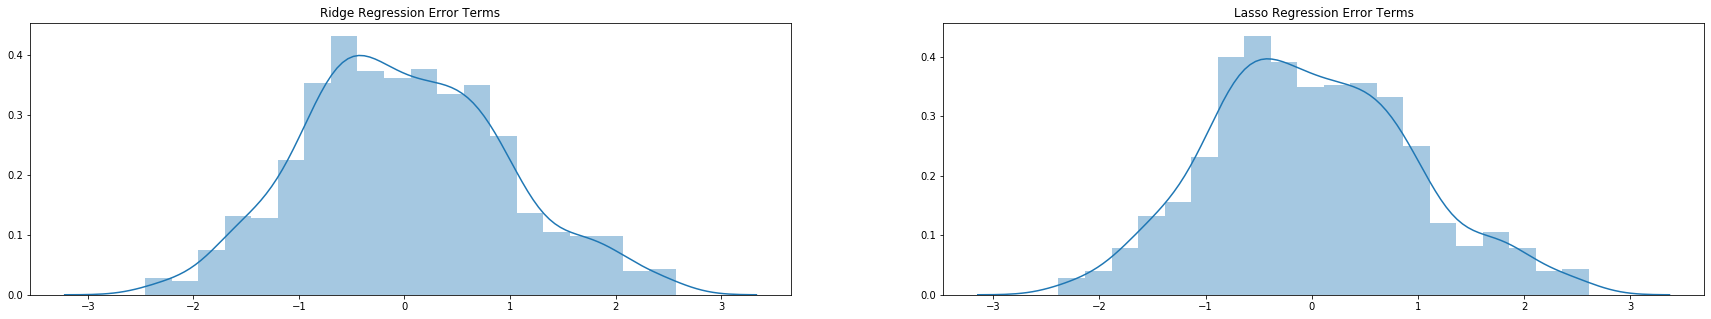

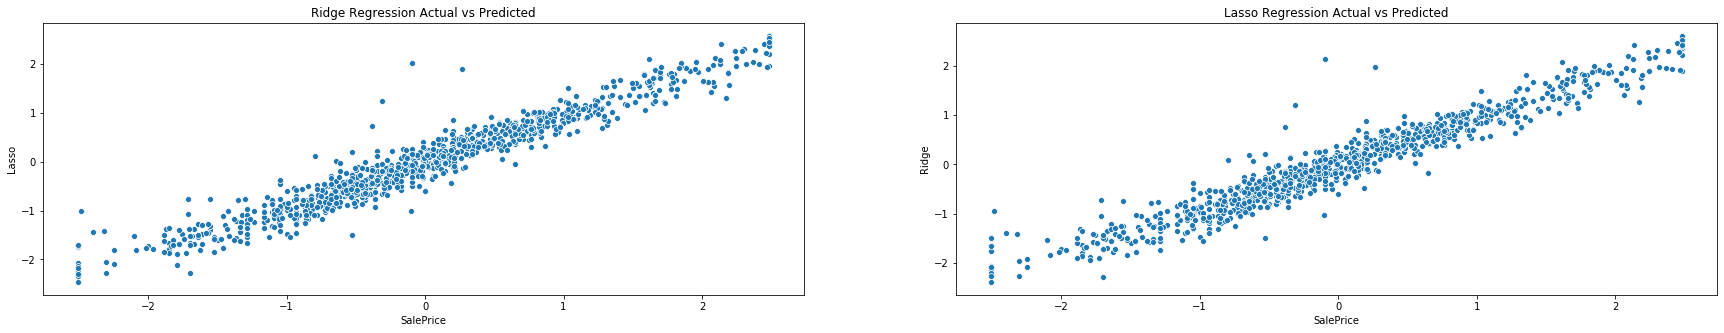

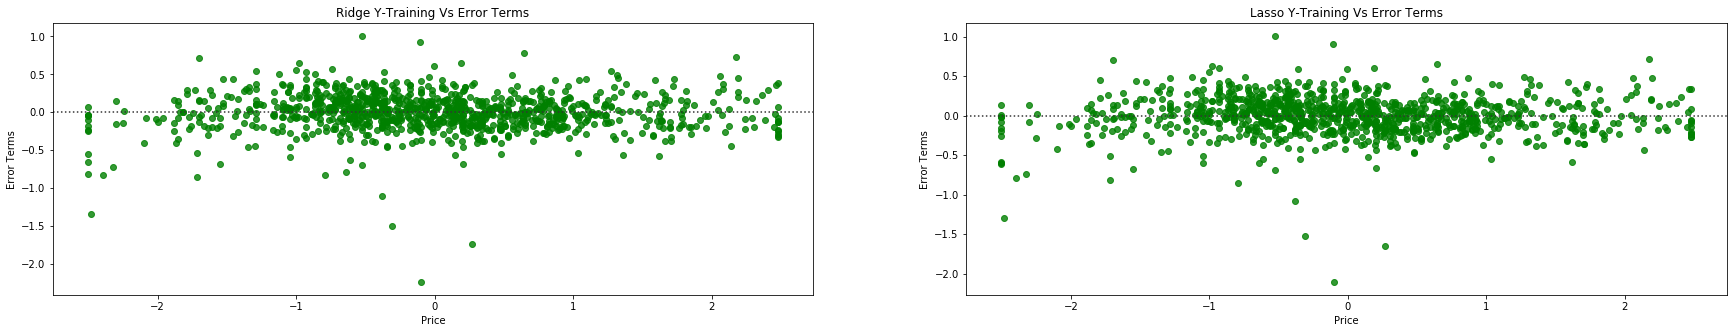

In [303]:
# Regression Validation between Lasso & Ridge

#Error Terms Distribution 

plt.figure(figsize=(30,5))
plt.subplot(1,2,1)
#pd.DataFrame(fit_ridge.predict(X_test))
sns.distplot(fit_ridge.predict(X_train))
plt.title("Ridge Regression Error Terms")

plt.subplot(1,2,2)
#pd.DataFrame(fit_ridge.predict(X_test))
sns.distplot(fit_lasso.predict(X_train))
plt.title("Lasso Regression Error Terms")
plt.show()

plt.figure(figsize=(30,5))
plt.subplot(1,2,1)
_temp = y_train 
_temp["Lasso"] = fit_ridge.predict(X_train)
sns.scatterplot(x="SalePrice",y="Lasso",data=_temp)
plt.title("Ridge Regression Actual vs Predicted")

plt.subplot(1,2,2)
_temp["Ridge"] = fit_lasso.predict(X_train)
sns.scatterplot(x="SalePrice",y="Ridge",data=_temp)
plt.title("Lasso Regression Actual vs Predicted")
plt.show()


plt.figure(figsize=(30,5))
plt.subplot(1,2,1)
_error_terms = _temp.SalePrice - _temp.Ridge
sns.residplot(x=_temp.SalePrice,y=_error_terms,lowess=False, color="g")
plt.title("Ridge Y-Training Vs Error Terms")
plt.xlabel("Price")
plt.ylabel("Error Terms")


plt.subplot(1,2,2)
_error_terms = _temp.SalePrice - _temp.Lasso
sns.residplot(x=_temp.SalePrice,y=_error_terms,lowess=False, color="g")
plt.title("Lasso Y-Training Vs Error Terms")
plt.xlabel("Price")
plt.ylabel("Error Terms")
plt.show()

### Review comments 

- both tes and train scores were satisfactory giving approximatly similar results
- both the models Lass and Ridge also provided similar results with the different alphas (Ridge at the alpha =5 and Lasso Alpha =0.001)
- hence we will review how the model coefficients to understand  which are the factors influencing more price of properties

,Column_name,Ridge,Lasso
0,LotFrontage,-0.002904,0.000365
1,LotArea,0.027692,0.031177
2,OverallQual,0.156304,0.169534
3,OverallCond,0.116994,0.127940
4,MasVnrArea,-0.008626,-0.005124


,Column_name,Ridge,Lasso
206,SaleCondition_Alloca,0.077065,0.000000
207,SaleCondition_Family,-0.059153,-0.061466
208,SaleCondition_Normal,0.058852,0.000000
209,SaleCondition_Partial,-0.030149,0.000000
210,constant,-0.504009,-0.321090


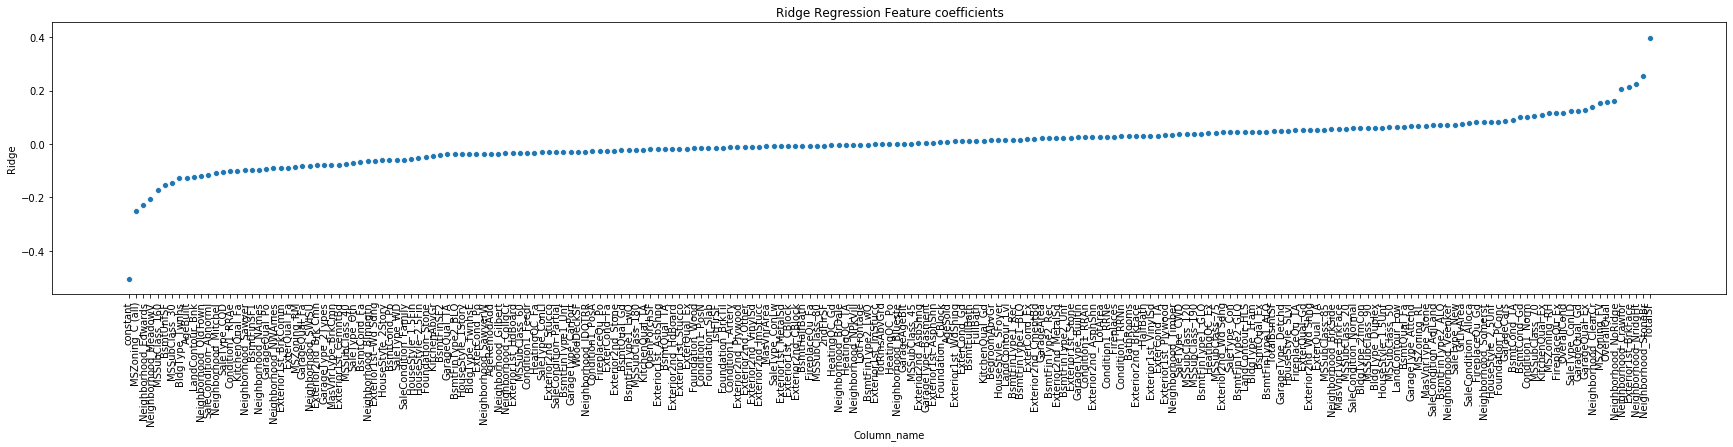

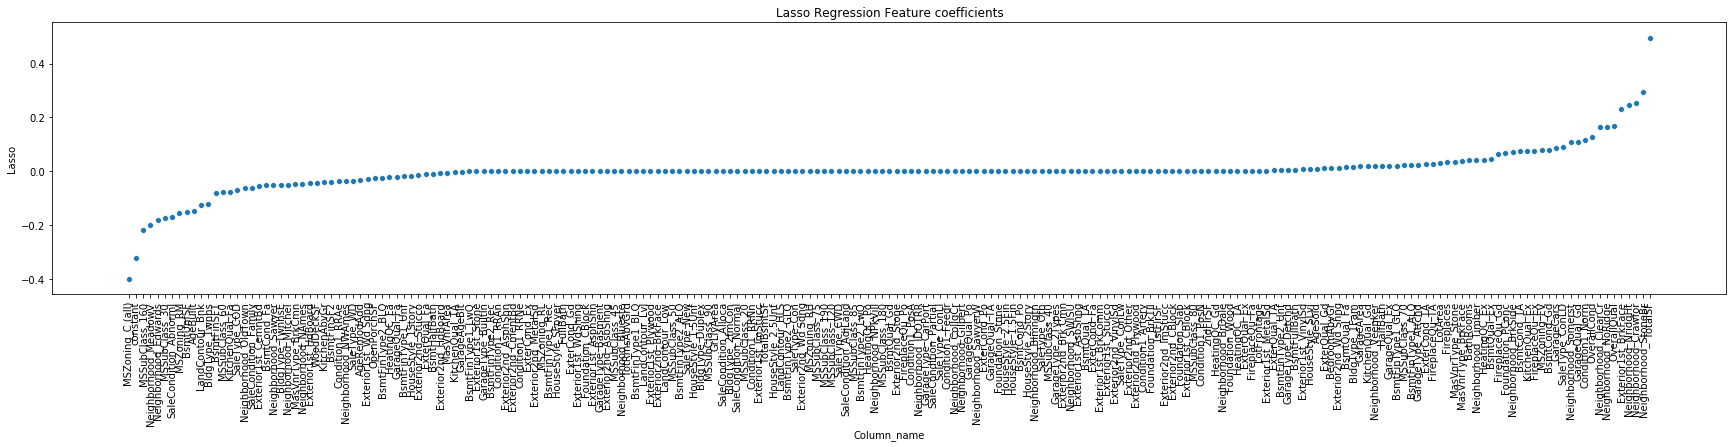

### Top features through Ridge Regression

,Column_name,Ridge
210,constant,-0.504009
29,TotalSF,0.396958
76,Neighborhood_StoneBr,0.256035
45,MSZoning_C (all),-0.252387
61,Neighborhood_Edwards,-0.227790
70,Neighborhood_NridgHt,0.225110
104,Exterior1st_BrkFace,0.212109
64,Neighborhood_MeadowV,-0.205405
60,Neighborhood_Crawfor,0.204774
42,MSSubClass_160,-0.170311


### Top features through Lasso Regression

,Column_name,Lasso
29,TotalSF,0.494684
45,MSZoning_C (all),-0.398254
210,constant,-0.321090
76,Neighborhood_StoneBr,0.296028
60,Neighborhood_Crawfor,0.251942
70,Neighborhood_NridgHt,0.244491
104,Exterior1st_BrkFace,0.230477
42,MSSubClass_160,-0.218602
64,Neighborhood_MeadowV,-0.197995
61,Neighborhood_Edwards,-0.180089


### Ridge Number of Features with Zero coefficients : 2 

### Lasso Number of Features with Zero coefficients : 108 

In [330]:
#lm_ridge.coef_

results = pd.DataFrame(X_train.columns)
results.columns =["Column_name"]
results["Ridge"] = lm_ridge.coef_.tolist()[0]
results["Lasso"] = lm_lasso.coef_.tolist()
_dic={"Column_name":"constant","Ridge":lm_ridge.intercept_[0],"Lasso":lm_lasso.intercept_[0]}

results=results.append(_dic,ignore_index=True)

display(results.head(),results.tail())

results=results.sort_values(by="Ridge")
plt.figure(figsize=(30,5))
sns.scatterplot(x="Column_name", y="Ridge", data=results)
plt.xticks(rotation=90)
plt.title("Ridge Regression Feature coefficients")
plt.show()

results=results.sort_values(by="Lasso")
plt.figure(figsize=(30,5))
sns.scatterplot(x="Column_name", y=results.Lasso, data=results)
plt.title("Lasso Regression Feature coefficients")
plt.xticks(rotation=90)
plt.show()


results["Abs_Ridge"] = results["Ridge"].abs()
results["Abs_Lasso"] = results["Lasso"].abs()

printmd("### Top features through Ridge Regression")
display(results.sort_values(by="Abs_Ridge",ascending=False)[["Column_name","Ridge"]].head(20))

printmd("### Top features through Lasso Regression")
display(results.sort_values(by="Abs_Lasso",ascending=False)[["Column_name","Lasso"]].head(20))


printmd(f"### Ridge Number of Features with Zero coefficients : {results[results.Ridge ==0].shape[0] } ")

printmd(f"### Lasso Number of Features with Zero coefficients : {results[results.Lasso ==0].shape[0] } ")


In [347]:
# coefficients evaluated by the model with the zero  by Lasso Algorithem

sorted(list(results.loc[(results.Lasso==0)].Column_name))

['1stFlrSF',
 '2ndFlrSF',
 'BldgType_2fmCon',
 'BldgType_Duplex',
 'BsmtCond_Po',
 'BsmtFinType1_BLQ',
 'BsmtFinType1_Rec',
 'BsmtFinType2_ALQ',
 'BsmtFinType2_GLQ',
 'BsmtFinType2_LwQ',
 'BsmtFinType2_Rec',
 'BsmtQual_Gd',
 'BsmtQual_TA',
 'Condition1_Artery',
 'Condition1_Feedr',
 'Condition1_PosA',
 'Condition1_PosN',
 'Condition1_RRAn',
 'Condition1_RRNe',
 'Condition1_RRNn',
 'ExterCond_Ex',
 'ExterCond_Fa',
 'ExterCond_Gd',
 'ExterCond_Po',
 'ExterQual_Ex',
 'Exterior1st_AsbShng',
 'Exterior1st_AsphShn',
 'Exterior1st_BrkComm',
 'Exterior1st_CBlock',
 'Exterior1st_ImStucc',
 'Exterior1st_Plywood',
 'Exterior1st_Stone',
 'Exterior1st_Stucco',
 'Exterior1st_WdShing',
 'Exterior2nd_AsbShng',
 'Exterior2nd_AsphShn',
 'Exterior2nd_Brk Cmn',
 'Exterior2nd_BrkFace',
 'Exterior2nd_CBlock',
 'Exterior2nd_CmentBd',
 'Exterior2nd_ImStucc',
 'Exterior2nd_MetalSd',
 'Exterior2nd_Other',
 'Exterior2nd_Plywood',
 'Exterior2nd_Stone',
 'Exterior2nd_VinylSd',
 'Exterior2nd_Wd Sdng',
 'FireplaceQu

### Below code is used only for simulate all trsnformation done on the unseen data for Kaggle compitation

In [187]:
# This code block is for applying trsnformation for unseen data and rescaling back traget variables.

ktest=pd.read_csv("Data/test.csv")

_results =pd.DataFrame(ktest.Id)
ktest=ktest.drop(["Id"],axis=1)

ktest[["MSSubClass"]]=ktest[["MSSubClass"]].astype(object)


_temp_dummies_set_1=pd.get_dummies(ktest[var_categorical_fields])
ktest=pd.concat([ktest,_temp_dummies_set_1],axis=1)
ktest=ktest.drop(var_categorical_fields,axis=1)

lst = set(X_train.columns)- set(ktest.columns) 


X_train["BathRooms"]= data_set_stage1.BsmtFullBath.fillna(0) + data_set_stage1.BsmtHalfBath.fillna(0) *0.5 +data_set_stage1.FullBath.fillna(0) +data_set_stage1.HalfBath.fillna(0) *0.5

data_set_stage1["TotalSF"]= data_set_stage1.BsmtFinSF1.fillna(0) + data_set_stage1.BsmtFinSF2.fillna(0) +data_set_stage1.BsmtUnfSF.fillna(1) +data_set_stage1["1stFlrSF"].fillna(0)+data_set_stage1["2ndFlrSF"].fillna(0)  + data_set_stage1.WoodDeckSF.fillna(0) +data_set_stage1.OpenPorchSF.fillna(0)



for i in lst:
    ktest[i] =0
    
ktest=ktest.fillna(0)

ktest[var_numarical_fields]=scaler.transform(ktest[var_numarical_fields])

ktest=ktest[X_train.columns]

re=fit_lasso.predict(ktest)

_results["SalePrice"]=scaler_target.inverse_transform(re)

_results["SalePrice"] = np.expm1(_results["SalePrice"] )

_results.to_csv("output.csv", index=False)

## Review Summary 

- Initially while reviewing bivariate analysis i have though that number of rooms and number bathrooms and squre meters properties  influence house price. however results are completely came as surprise it is indict

- Basic Data Cleaning were done such as 
    - Taken Target Variable into Log Scale insted of actual values to aviod  skewness 
    - Created new derived fields such as age of property and age and when the property was remodeled
    - created Total SF from all other Squere Feets properties  
    - Deleted few fields where category columns is either majorly contain the single level or NA properties 
    - Review the features comparing with the Target Variables 
    
- Model development 

    - Explore the model development options with the standard linear regression with the combinations  of RFE. understand that Model unstable with the number of features results highly varing between test and training data set.
    - Experiment conducted with the different Regulization techniques by balancing hyper parameters (such as number of features and alpha values)
    - Identified <b> alpha =5 is better fit for the Ridge Regression </b> with complete features list
    - Identified <b> alpha =0.01 is better fit for the Lasso Regression</b> with complete features list
    - Both Lass and Ridge regressions indicating that along with the number of features reduced model performence is went down.

- Model findings

    - Indicates that Total SF (Squere Feet) of a property significantly correlated with the price of property
    - indicates that location's like (Stone Brook,  Northridge Heights) are indicating prime area if properies are related to this area indicating high prices.
    - indicates that locations like Meadow Village, Edwards) are indicating low price areas target variables is -ve correlated.
    - Interesting if zone is classified as  Commercial zone price is turn to be low.
    - If property is Exterior covering  with the bricks Brick Face indicating +ve correlated by both models.
    
    
- Model Comparsions 

    - Ridge regression indicates only 2 variables having coefficients are zero where in Lass it gives total of 108 feature coefficients are calculated as zero out of 211 columns 
    - The following places are indicates that these are not price sensitive <b> [ Blmngtn, Blueste, BrDale, CollgCr, Gilbert ,IDOTRR, NPkVill, SWISU, SawyerW ] </b>
    - <b> MSSubClass major number of categories are not helping deriving price proposition</b>
    - <b> surpricing 1stFlrSF, 2stFlrSF  coefficients became zero by the Lasso however Total SF (which is derived field indicates that highly signify) </b>
    - Lasso regulization help to determin to focus on the list of features were influence the model. in cas of ridge high influence variables were having higher coefficients
 
- Regression Evaluation 
    - Verified that Error Terms created by the both Ridge and Lasso were normally distributed 
    - all other fundamential principals were satstfactory with both Lasso and Ridge Regressions.
    